# 5051 Project 1

Author：    LAN Tianwei 藍天蔚<br>
ID：        21230969<br>
Email：     tlanaa@connect.ust.hk<br>

All the following sorting algorithms were implemented by me in self-practice, without any assistance from AI, external libraries, or built-in functions.

# Algorithms

In [ ]:
# insert sort
def insert_sort(a):
    n = len(a)
    for i in range(1, n):
        key = a[i]
        j = i - 1
        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = key
    return a


# a = [6, 5, 2, 4, 9, 7, 0, 1, 3, 8]
# insert_sort(a)
# print(a)

In [ ]:
# Bubble Sort
def bubble_sort(A):
    swap = -1
    pass_num = 0
    while swap != 0:
        swap = 0
        for i in range(1,len(A)-pass_num):
            if A[i-1] > A[i]:
                A[i-1], A[i] = A[i], A[i-1] 
                swap += 1
        pass_num += 1
    return A


# A = [6,5,2,4,9,7,0,1,3,8]
# B = bubble_sort(A)
# print(B)

In [3]:
# Quick Sort (Space Complexty O(logn))

def quick_sort(A):
    if len(A) <= 1:
        return A
    
    pivot = A[len(A) // 2]
    
    left = []
    middle = []
    right = []
    
    for x in A:
        if x < pivot:
            left.append(x)
        elif x == pivot:
            middle.append(x)
        else:
            right.append(x)
    
    return quick_sort(left) + middle + quick_sort(right)

# A = [6,5,2,4,9,7,0,1,3,8]
# B = quick_sort(A)
# print(B)

In [ ]:
# MergeSort
import math

def merge_sort(a):                      
    if len(a) < 2:                      
        return a[:]
    mid = math.ceil(len(a)/2)
    left = merge_sort(a[:mid])          
    right = merge_sort(a[mid:])         
    return merge(left, right)           

def merge(left, right):                 
    i = j = 0                           
    res = []
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            res.append(left[i])
            i += 1
        else:
            res.append(right[j])
            j += 1
    res.extend(left[i:])                
    res.extend(right[j:])
    return res



# A = [6, 5, 2, 4, 9, 7, 0, 1, 3, 8]
# print(merge_sort(A)) 

In [ ]:
# HeapSort
def heap_sort(a):
    n = len(a)
    for i in range(n // 2 - 1, -1, -1):
        _down(a, i, n)

    for size in range(n - 1, 0, -1):
        a[0], a[size] = a[size], a[0]
        _down(a, 0, size)
    return a

# max_heapify
def _down(a, i, size):
    while True:
        l = 2 * i + 1 
        r = l + 1     
        largest = i
        if l < size and a[l] > a[largest]:
            largest = l
        if r < size and a[r] > a[largest]:
            largest = r
        if largest == i:
            break
        a[i], a[largest] = a[largest], a[i]
        i = largest

# nums = [6, 2, 9, 0, 4, 5, 1, 3, 8, 7]
# heap_sort(nums)
# print(nums)          # -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
# Counting Sort
def counting_sort(arr):
    if not arr:
        return []
    
    for x in arr:
        if not isinstance(x, int) or x < 0:
            raise ValueError("Only support non-negative integer as input")
    
    max_val = max(arr)
    count = [0] * (max_val + 1)
    
    for num in arr:
        count[num] += 1
    
    sorted_arr = []
    for value in range(len(count)):
        freq = count[value]
        sorted_arr.extend([value] * freq)
    
    return sorted_arr

In [ ]:
# Radix Sort
def radix_sort(arr):
    if not arr:
        return []
    
    for x in arr:
        if not isinstance(x, int) or x < 0:
            raise ValueError("Only support non-negative integer as input")
    
    max_val = max(arr)
    exp = 1 
    output = arr[:]  
    
    while max_val // exp > 0:
        buckets = [[] for _ in range(10)]
        
        for num in output:
            digit = (num // exp) % 10
            buckets[digit].append(num)
        
        output = []
        for bucket in buckets:
            output.extend(bucket)
        
        exp *= 10
    
    return output

# Experiments

## Reading and processing data

In [8]:
import pandas as pd

df = pd.read_csv("TDCS_M06A_20231204_080000.csv")
cols = [0, 1, 2, 5]
data = df.iloc[:, cols].copy()
data.columns = ['VehicleType', 'DirectionTime_O', 'GantryID_O', 'TripLength']

data['DirectionTime_O'] = pd.to_datetime(data['DirectionTime_O']) 
data['GantryID_O'] = data['GantryID_O'].astype('string') 

print(data.dtypes)
print('\n')
print(data.head(5))

VehicleType                 int64
DirectionTime_O    datetime64[ns]
GantryID_O         string[python]
TripLength                float64
dtype: object


   VehicleType     DirectionTime_O GantryID_O  TripLength
0           32 2023-12-04 08:16:35   01F3185N       20.03
1           31 2023-12-04 08:20:36   01F0578S       13.00
2           31 2023-12-04 08:02:25   03F0498N       19.50
3           31 2023-12-04 08:15:54   01F0467N       25.90
4           32 2023-12-04 08:24:01   03F3854N       34.60


## Experiment function


Function：benchmark_sort_algorithm

Benchmark the runtime of applying a specified sorting algorithm to selected columns of the DataFrame.

Parameters:
- data (pd.DataFrame): Input dataset.
- columns_to_sort (list[str]): Column names to test.
- base_ratio (float): Base sampling ratio (e.g., 0.01 for 1%).
- sort_func (callable): In-place sorting function that takes one list argument.
- func_name (str): Name of the sorting function (for logging).
- repeats (int, optional): Number of trials per sample size (default: 5).
- seed (int, optional): Random seed for reproducibility (default: 21230969).

Returns:
- dict: Maps each column name to a DataFrame with columns ratio, n, avg_time, and std_time.

In [10]:
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def benchmark_sort_algorithm(data, columns_to_sort, base_ratio, sort_func, func_name, repeats=5, seed=21230969):
    random.seed(seed)
    multipliers = [1/5, 1/4, 1/3, 1/2, 1]
    ratios = base_ratio * np.array(multipliers)
    
    all_results = {}
    
    for column_to_sort in columns_to_sort:
        print(f"\nProcessing column: {column_to_sort} with {func_name}")
        values = data[column_to_sort].dropna().tolist()
        N_total = len(values)
        print(f"total: {N_total}")

        results = []
        for ratio in ratios:
            n = int(N_total * ratio)
            if n < 2:
                continue
            times = []
            valid_trial = True
            for _ in range(repeats):
                try:
                    sample = random.sample(values, n)
                    arr = copy.deepcopy(sample)
                    start = time.perf_counter()
                    sort_func(arr)
                    end = time.perf_counter()
                    times.append(end - start)
                except Exception as e:
                    print(f"  Warning: failed on n={n} for {column_to_sort}: {e}")
                    valid_trial = False
                    break
            if not valid_trial or not times:
                continue
            avg_time = np.mean(times)
            results.append({
                'ratio': ratio,
                'n': n,
                'avg_time': avg_time,
                'std_time': np.std(times)
            })
            print(f"ratio {ratio:.1%} | n={n} | avg_time={avg_time:.6f}s")
        
        all_results[column_to_sort] = pd.DataFrame(results)
    
    return all_results

## Insert Sort ($O(n^2$))

In [37]:
columns_to_sort = ['VehicleType', 'DirectionTime_O', 'GantryID_O', 'TripLength']
all_results_insert = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 0.01,
    sort_func = insert_sort,
    func_name = "insert_sort",
    repeats = 5,
    seed = 21230969
)


Processing column: VehicleType with insert_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.004478s
ratio 0.2% | n=568 | avg_time=0.006520s
ratio 0.3% | n=758 | avg_time=0.012358s
ratio 0.5% | n=1137 | avg_time=0.026359s
ratio 1.0% | n=2275 | avg_time=0.100527s

Processing column: DirectionTime_O with insert_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.011411s
ratio 0.2% | n=568 | avg_time=0.017903s
ratio 0.3% | n=758 | avg_time=0.031573s
ratio 0.5% | n=1137 | avg_time=0.074412s
ratio 1.0% | n=2275 | avg_time=0.291865s

Processing column: GantryID_O with insert_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.008752s
ratio 0.2% | n=568 | avg_time=0.014090s
ratio 0.3% | n=758 | avg_time=0.025308s
ratio 0.5% | n=1137 | avg_time=0.055885s
ratio 1.0% | n=2275 | avg_time=0.220295s

Processing column: TripLength with insert_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.008590s
ratio 0.2% | n=568 | avg_time=0.013330s
ratio 0.3% | n=758 | avg_time=0.024660s
ratio 0.5% | n=1137 

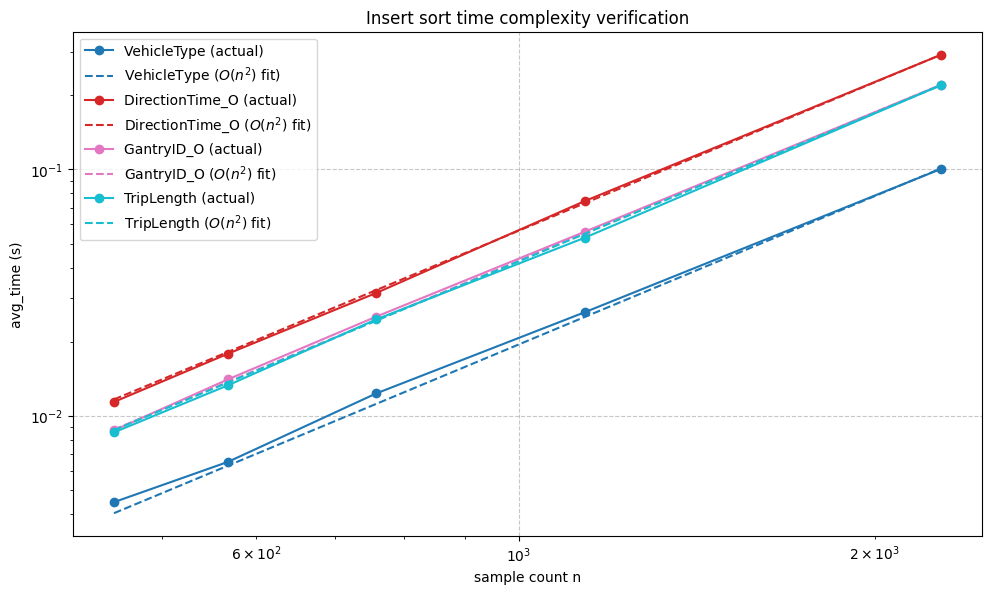

In [ ]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_insert or all_results_insert[column].empty:
        continue
    df = all_results_insert[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    # Quadratic fit: t = a * n^2
    n_vals = df['n'].values
    t_vals = df['avg_time'].values
    n2 = n_vals ** 2
    a = np.dot(t_vals, n2) / np.dot(n2, n2)
    
    o_n2 = a * n_vals ** 2
    plt.plot(n_vals, o_n2, '--', color=colors[idx], label=f'{column} ($O(n^2)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Insert sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.savefig("insert.png")
plt.show()

## Bubble Sort ($O(n^2)$)

In [40]:
columns_to_sort = ['VehicleType', 'DirectionTime_O', 'GantryID_O', 'TripLength']
all_results_bubble = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 0.01,
    sort_func = bubble_sort,
    func_name = "bubble_sort",
    repeats = 5,
    seed = 21230969
)


Processing column: VehicleType with bubble_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.012461s
ratio 0.2% | n=568 | avg_time=0.020330s
ratio 0.3% | n=758 | avg_time=0.036646s
ratio 0.5% | n=1137 | avg_time=0.082829s
ratio 1.0% | n=2275 | avg_time=0.344202s

Processing column: DirectionTime_O with bubble_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.022804s
ratio 0.2% | n=568 | avg_time=0.035530s
ratio 0.3% | n=758 | avg_time=0.066681s
ratio 0.5% | n=1137 | avg_time=0.149318s
ratio 1.0% | n=2275 | avg_time=0.610928s

Processing column: GantryID_O with bubble_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.017989s
ratio 0.2% | n=568 | avg_time=0.029798s
ratio 0.3% | n=758 | avg_time=0.052635s
ratio 0.5% | n=1137 | avg_time=0.120382s
ratio 1.0% | n=2275 | avg_time=0.482050s

Processing column: TripLength with bubble_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.017670s
ratio 0.2% | n=568 | avg_time=0.028528s
ratio 0.3% | n=758 | avg_time=0.052175s
ratio 0.5% | n=1137 

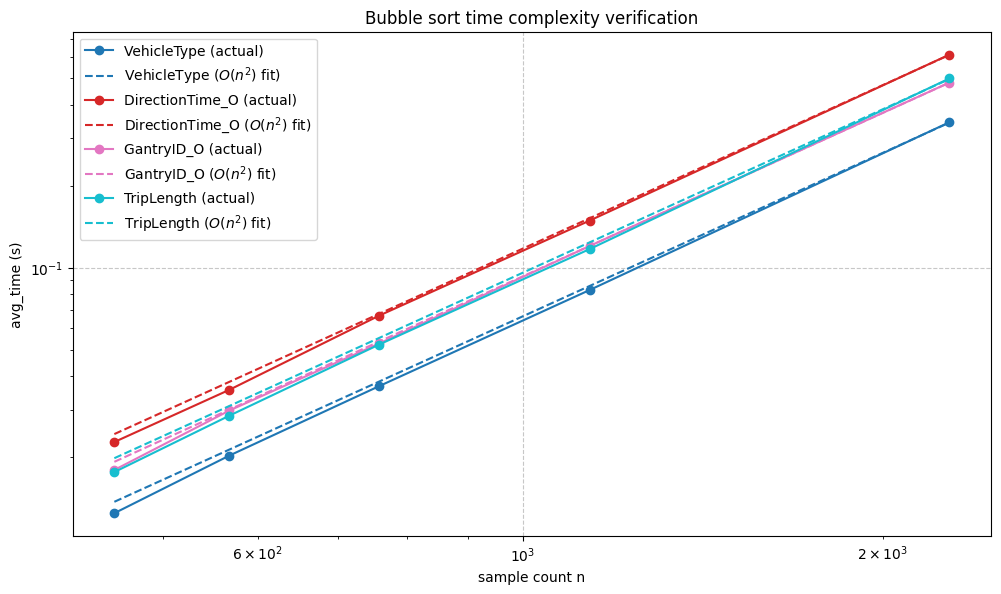

In [41]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_bubble or all_results_bubble[column].empty:
        continue
    df = all_results_bubble[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    # Quadratic fit: t = a * n^2
    n_vals = df['n'].values
    t_vals = df['avg_time'].values
    n2 = n_vals ** 2
    a = np.dot(t_vals, n2) / np.dot(n2, n2)
    
    o_n2 = a * n_vals ** 2
    plt.plot(n_vals, o_n2, '--', color=colors[idx], label=f'{column} ($O(n^2)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Bubble sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.savefig("bubble.png")
plt.show()

## Quick Sort ($O(nlogn)$)

In [73]:
columns_to_sort = ['VehicleType', 'DirectionTime_O', 'GantryID_O', 'TripLength']
all_results_quick = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 0.01,
    sort_func = quick_sort,
    func_name = "quick_sort",
    repeats = 5,
    seed = 21230969
)


Processing column: VehicleType with quick_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.000091s
ratio 0.2% | n=568 | avg_time=0.000112s
ratio 0.3% | n=758 | avg_time=0.000161s
ratio 0.5% | n=1137 | avg_time=0.000228s
ratio 1.0% | n=2275 | avg_time=0.000436s

Processing column: DirectionTime_O with quick_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.001112s
ratio 0.2% | n=568 | avg_time=0.001442s
ratio 0.3% | n=758 | avg_time=0.002052s
ratio 0.5% | n=1137 | avg_time=0.003070s
ratio 1.0% | n=2275 | avg_time=0.006667s

Processing column: GantryID_O with quick_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.000578s
ratio 0.2% | n=568 | avg_time=0.000703s
ratio 0.3% | n=758 | avg_time=0.000975s
ratio 0.5% | n=1137 | avg_time=0.001439s
ratio 1.0% | n=2275 | avg_time=0.002791s

Processing column: TripLength with quick_sort
total: 227568
ratio 0.2% | n=455 | avg_time=0.000647s
ratio 0.2% | n=568 | avg_time=0.000961s
ratio 0.3% | n=758 | avg_time=0.001133s
ratio 0.5% | n=1137 | av

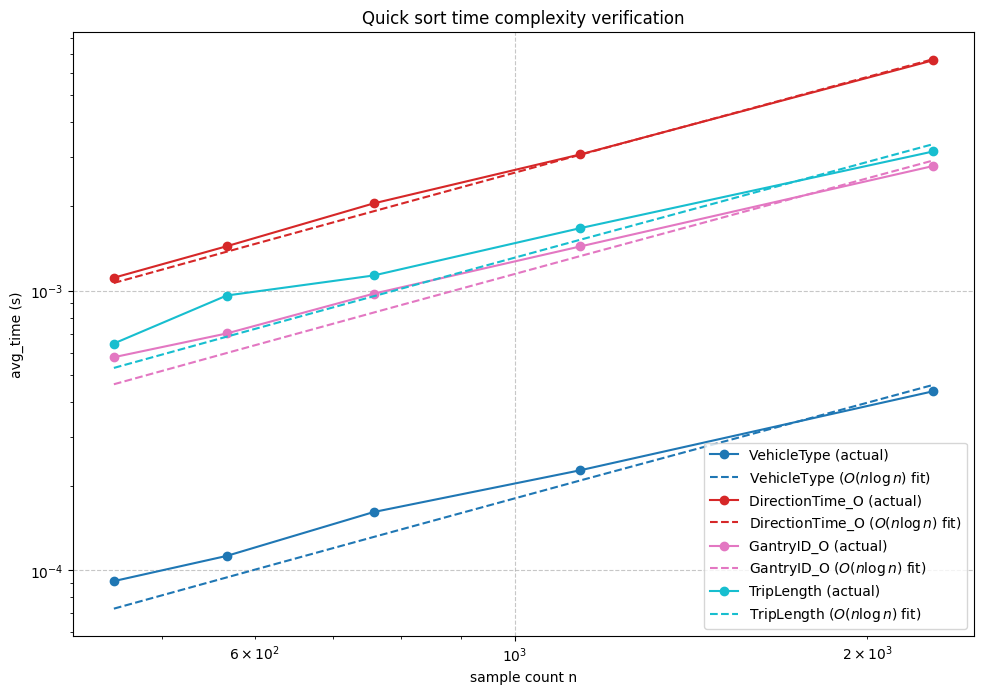

In [74]:
plt.figure(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_quick or all_results_quick[column].empty:
        continue
    df = all_results_quick[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    n_vals = df['n'].values
    t_vals = df['avg_time'].values

    n_log_n = n_vals * np.log(n_vals)
    
    # Linear regression through origin: t ≈ a * (n log n)
    a = np.dot(t_vals, n_log_n) / np.dot(n_log_n, n_log_n)
    
    o_nlogn = a * n_log_n
    plt.plot(n_vals, o_nlogn, '--', color=colors[idx], label=f'{column} ($O(n \\log n)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Quick sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.savefig('quick.png')
plt.show()

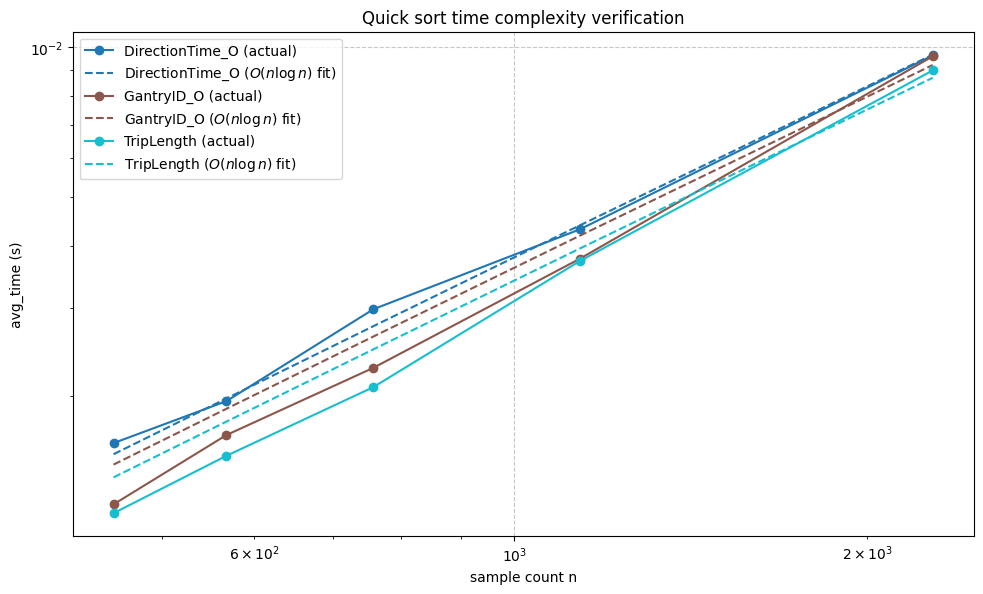

In [56]:
columns_to_sort = ['DirectionTime_O', 'GantryID_O', 'TripLength']

plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_quick or all_results_quick[column].empty:
        continue
    df = all_results_quick[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    n_vals = df['n'].values
    t_vals = df['avg_time'].values

    n_log_n = n_vals * np.log(n_vals)
    
    # Linear regression through origin: t ≈ a * (n log n)
    a = np.dot(t_vals, n_log_n) / np.dot(n_log_n, n_log_n)
    
    o_nlogn = a * n_log_n
    plt.plot(n_vals, o_nlogn, '--', color=colors[idx], label=f'{column} ($O(n \\log n)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Quick sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.savefig('quick_2.png')
plt.show()

## Merge Sort ($O(nlogn)$)

In [65]:
columns_to_sort = ['VehicleType', 'DirectionTime_O', 'GantryID_O', 'TripLength']
all_results_merge = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 0.1,
    sort_func = merge_sort,
    func_name = "merge_sort",
    repeats = 5,
    seed = 21230969
)


Processing column: VehicleType with merge_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.018504s
ratio 2.5% | n=5689 | avg_time=0.023350s
ratio 3.3% | n=7585 | avg_time=0.031324s
ratio 5.0% | n=11378 | avg_time=0.049604s
ratio 10.0% | n=22756 | avg_time=0.106538s

Processing column: DirectionTime_O with merge_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.022953s
ratio 2.5% | n=5689 | avg_time=0.029246s
ratio 3.3% | n=7585 | avg_time=0.039492s
ratio 5.0% | n=11378 | avg_time=0.064035s
ratio 10.0% | n=22756 | avg_time=0.139413s

Processing column: GantryID_O with merge_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.019145s
ratio 2.5% | n=5689 | avg_time=0.025842s
ratio 3.3% | n=7585 | avg_time=0.034172s
ratio 5.0% | n=11378 | avg_time=0.053022s
ratio 10.0% | n=22756 | avg_time=0.113371s

Processing column: TripLength with merge_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.020486s
ratio 2.5% | n=5689 | avg_time=0.026169s
ratio 3.3% | n=7585 | avg_time=0.034913s
rat

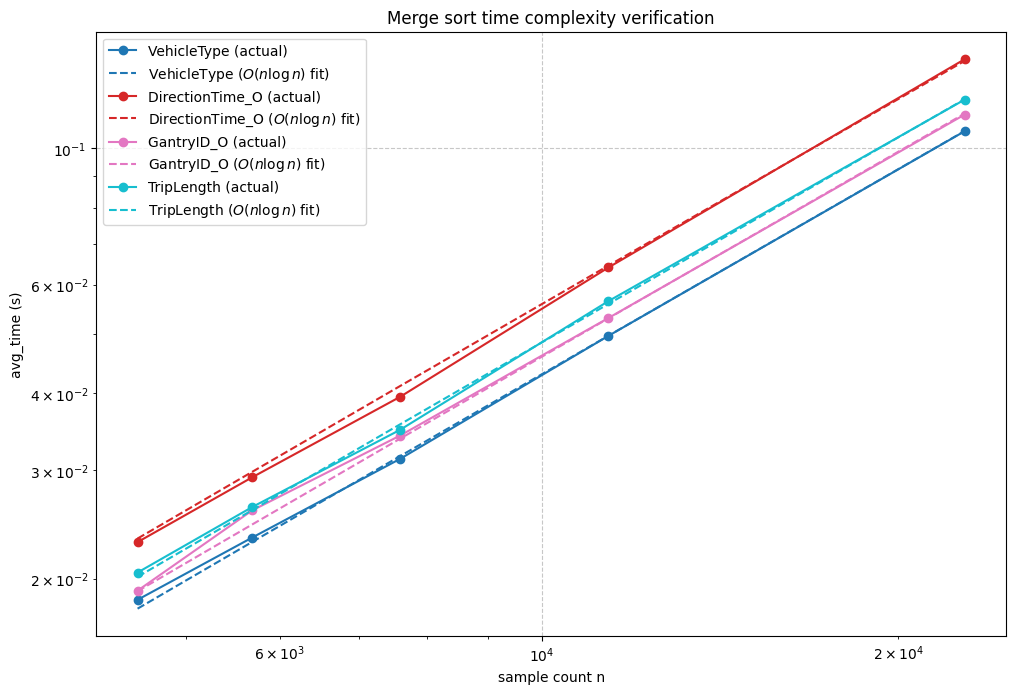

In [67]:
plt.figure(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_merge or all_results_merge[column].empty:
        continue
    df = all_results_merge[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    n_vals = df['n'].values
    t_vals = df['avg_time'].values

    n_log_n = n_vals * np.log(n_vals)
    
    # Linear regression through origin: t ≈ a * (n log n)
    a = np.dot(t_vals, n_log_n) / np.dot(n_log_n, n_log_n)
    
    o_nlogn = a * n_log_n
    plt.plot(n_vals, o_nlogn, '--', color=colors[idx], label=f'{column} ($O(n \\log n)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Merge sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.savefig('merge.png')
plt.show()

## Heap Sort ($O(nlogn)$)

In [68]:
columns_to_sort = ['VehicleType', 'DirectionTime_O', 'GantryID_O', 'TripLength']
all_results_heap = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 0.1,
    sort_func = heap_sort,
    func_name = "heap_sort",
    repeats = 5,
    seed = 21230969
)


Processing column: VehicleType with heap_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.010024s
ratio 2.5% | n=5689 | avg_time=0.012347s
ratio 3.3% | n=7585 | avg_time=0.017791s
ratio 5.0% | n=11378 | avg_time=0.027066s
ratio 10.0% | n=22756 | avg_time=0.055684s

Processing column: DirectionTime_O with heap_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.027078s
ratio 2.5% | n=5689 | avg_time=0.035757s
ratio 3.3% | n=7585 | avg_time=0.049369s
ratio 5.0% | n=11378 | avg_time=0.079566s
ratio 10.0% | n=22756 | avg_time=0.184650s

Processing column: GantryID_O with heap_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.022099s
ratio 2.5% | n=5689 | avg_time=0.029566s
ratio 3.3% | n=7585 | avg_time=0.038837s
ratio 5.0% | n=11378 | avg_time=0.062234s
ratio 10.0% | n=22756 | avg_time=0.131013s

Processing column: TripLength with heap_sort
total: 227568
ratio 2.0% | n=4551 | avg_time=0.023277s
ratio 2.5% | n=5689 | avg_time=0.030460s
ratio 3.3% | n=7585 | avg_time=0.042693s
ratio 5

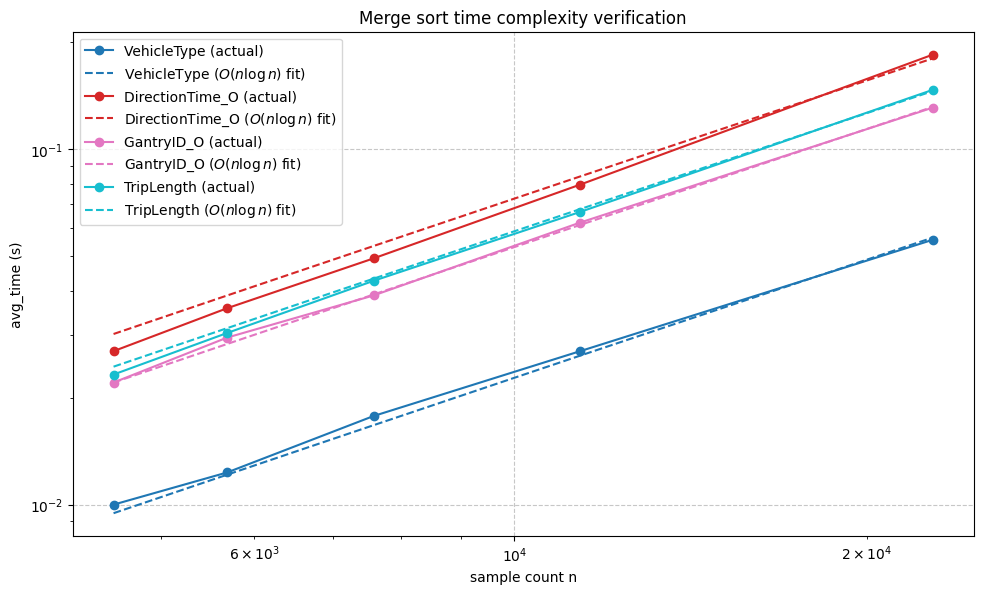

In [69]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_heap or all_results_heap[column].empty:
        continue
    df = all_results_heap[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    n_vals = df['n'].values
    t_vals = df['avg_time'].values

    n_log_n = n_vals * np.log(n_vals)
    
    # Linear regression through origin: t ≈ a * (n log n)
    a = np.dot(t_vals, n_log_n) / np.dot(n_log_n, n_log_n)
    
    o_nlogn = a * n_log_n
    plt.plot(n_vals, o_nlogn, '--', color=colors[idx], label=f'{column} ($O(n \\log n)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Merge sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.savefig('heap.png')
plt.show()

## Counting Sort ($O(n+k)$)

Counting sort only applies to relatively small positive integers, only the `VehicleType` column meets this condition.

In [22]:
columns_to_sort = ['VehicleType']
all_results_counting = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 1,
    sort_func = counting_sort,
    func_name = "counting_sort",
    repeats = 10,
    seed = 21230969
)


Processing column: VehicleType with counting_sort
total: 227568
ratio 20.0% | n=45513 | avg_time=0.002429s
ratio 25.0% | n=56892 | avg_time=0.002567s
ratio 33.3% | n=75856 | avg_time=0.003616s
ratio 50.0% | n=113784 | avg_time=0.005243s
ratio 100.0% | n=227568 | avg_time=0.010196s


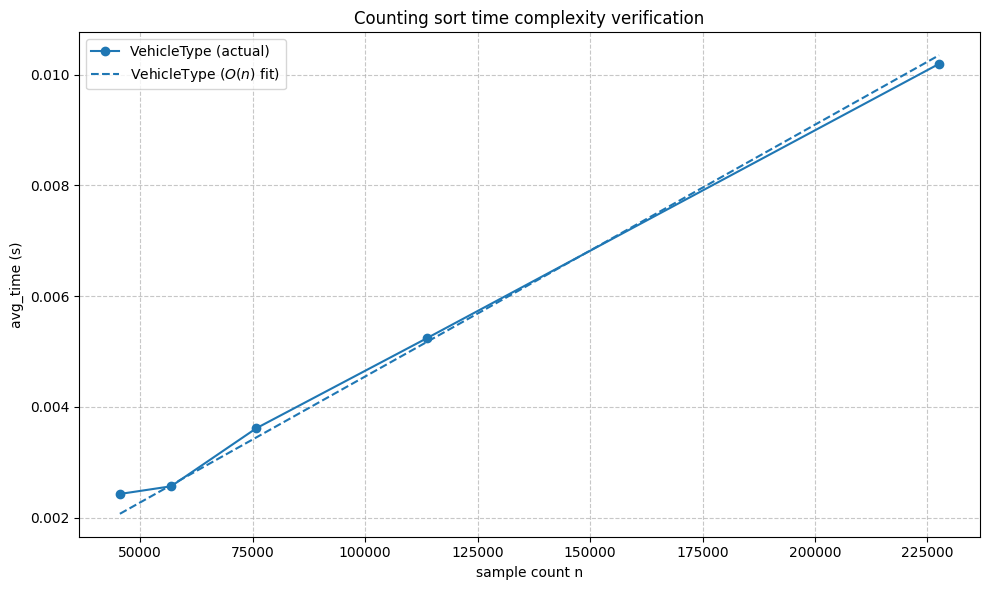

In [23]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_counting or all_results_counting[column].empty:
        continue
    df = all_results_counting[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    # Linear fit through origin: t = a * n
    n_vals = df['n'].values
    t_vals = df['avg_time'].values
    a = np.dot(t_vals, n_vals) / np.dot(n_vals, n_vals)
    
    o_n = a * n_vals
    plt.plot(n_vals, o_n, '--', color=colors[idx], label=f'{column} ($O(n)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Counting sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("counting.png")
plt.show()

## Radix Sort ($O(d·n)$)

In [24]:
columns_to_sort = ['VehicleType']
all_results_radix = benchmark_sort_algorithm(
    data=data,
    columns_to_sort=columns_to_sort,
    base_ratio = 1,
    sort_func = radix_sort,
    func_name = "radix_sort",
    repeats = 10,
    seed = 21230969
)


Processing column: VehicleType with radix_sort
total: 227568
ratio 20.0% | n=45513 | avg_time=0.003428s
ratio 25.0% | n=56892 | avg_time=0.004031s
ratio 33.3% | n=75856 | avg_time=0.005343s
ratio 50.0% | n=113784 | avg_time=0.008094s
ratio 100.0% | n=227568 | avg_time=0.015793s


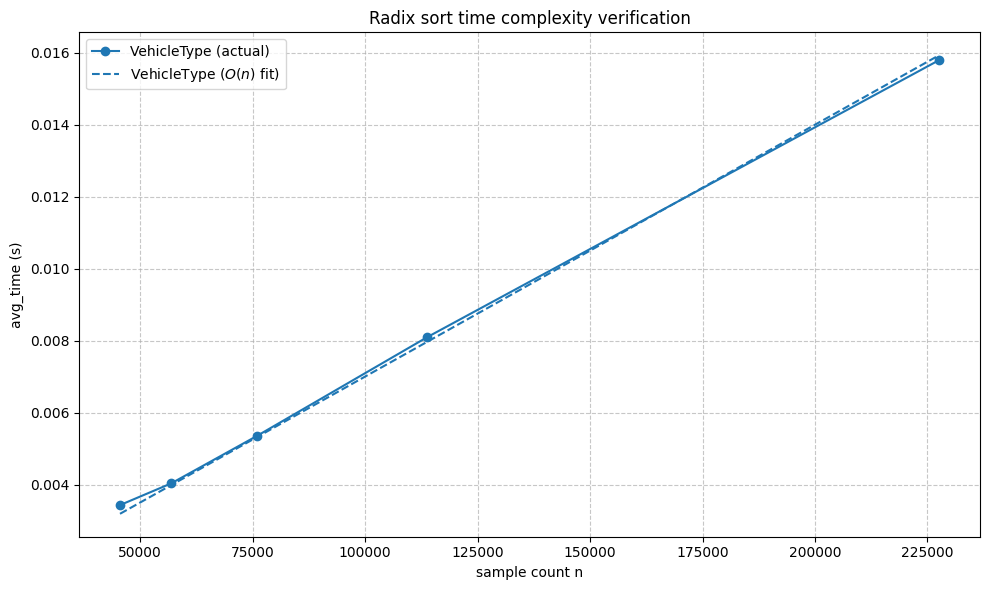

In [25]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(columns_to_sort)))
for idx, column in enumerate(columns_to_sort):
    if column not in all_results_radix or all_results_radix[column].empty:
        continue
    df = all_results_radix[column]
    plt.plot(df['n'], df['avg_time'], 'o-', color=colors[idx], label=f'{column} (actual)')

    # Linear fit through origin: t = a * n
    n_vals = df['n'].values
    t_vals = df['avg_time'].values
    a = np.dot(t_vals, n_vals) / np.dot(n_vals, n_vals)
    
    o_n = a * n_vals
    plt.plot(n_vals, o_n, '--', color=colors[idx], label=f'{column} ($O(n)$ fit)')

plt.xlabel('sample count n')
plt.ylabel('avg_time (s)')
plt.title('Radix sort time complexity verification')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("radix.png")
plt.show()